# PANDA 

## 1. Imports et configuration

On commence par charger des librairies simples et classiques :
- pandas et numpy pour les données
- matplotlib pour afficher
- tifffile pour lire les fichiers `.tiff`
- cv2 pour manipuler les images
- torch et timm pour les modèles

In [ ]:
import os
import gc
import math
import random
import warnings
from pathlib import Path

import cv2
//import tiffile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.notebook import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms as transforms
import timm

warnings.filterwarnings("ignore")

ModuleNotFoundError: No module named 'tiffile'

#### 1.a Chemins et paramètres

Ici on définit tous les chemins et les paramètres importants au même endroit, de cette manière si on veut changer quelque chose plus tard, ce sera plus simple.

In [ ]:
BASE_DIR = Path("/kaggle/input/competitions/prostate-cancer-grade-assessment")
TRAIN_CSV = BASE_DIR / "train.csv"
TEST_CSV = BASE_DIR / "test.csv"
TRAIN_IMAGES_DIR = BASE_DIR / "train_images"
MASKS_DIR = BASE_DIR / "train_label_masks"

WORK_DIR = Path("/kaggle/working")
PREPROCESS_DIR = WORK_DIR / "preprocessed_tiles"
PREPROCESS_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Paramètres image
IMAGE_LEVEL = 1
TILE_SIZE = 128
N_TILES = 16
GRID_SIZE = 4

# Paramètres entraînement
BATCH_SIZE = 8
NUM_EPOCHS = 3
LR = 1e-4
NUM_WORKERS = 2
NUM_CLASSES = 6

# Pour aller plus vite au début
USE_SUBSET = True
SUBSET_SIZE = 2000

print("DEVICE :", DEVICE)
print("BASE_DIR existe :", BASE_DIR.exists())
print("TRAIN_IMAGES_DIR existe :", TRAIN_IMAGES_DIR.exists())
print("MASKS_DIR existe :", MASKS_DIR.exists())

DEVICE : cuda
BASE_DIR existe : True
TRAIN_IMAGES_DIR existe : True
MASKS_DIR existe : True


#### 1.b Reproductibilité

Le but est d'avoir des résultats un peu plus stables.

In [ ]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

## 2. EDA - Analyse Exploratoire des Données 

On commence par lire `train.csv`.

On regarde :
- la taille du dataset
- les colonnes
- les valeurs manquantes
- la variable cible `isup_grade`
- la variable `gleason_score`
- les `data_provider`

In [ ]:
train_df = pd.read_csv(TRAIN_CSV)

if USE_SUBSET:
    train_df, _ = train_test_split(
        train_df,
        train_size=SUBSET_SIZE,
        stratify=train_df["isup_grade"],
        random_state=SEED
    )
    train_df = train_df.reset_index(drop=True)

print("Shape :", train_df.shape)
display(train_df.head())

print("Colonnes :")
print(train_df.columns.tolist())
print()

print("Valeurs manquantes :")
display(train_df.isna().sum())

Shape : (2000, 4)


,image_id,data_provider,isup_grade,gleason_score
0,87ead124230cbf0aa13bcfb238b7dcb6,radboud,3,4+3
1,810482a949cbe7f5cd785a1dd9f0122c,radboud,3,4+3
2,73c83151a4b6e0bbea3ce58f1f924308,karolinska,4,4+4
3,2694eb0781b846eb79f88ca295a821d5,karolinska,1,3+3
4,67bc9a23a87b07457464561b22515733,radboud,1,3+3


Colonnes :
['image_id', 'data_provider', 'isup_grade', 'gleason_score']

Valeurs manquantes :


image_id         0
data_provider    0
isup_grade       0
gleason_score    0
dtype: int64

### 2.a Distribution de la cible

`isup_grade` est notre cible principale.

C'est cette variable que l'on va essayer de prédire.

Elle va de 0 à 5.

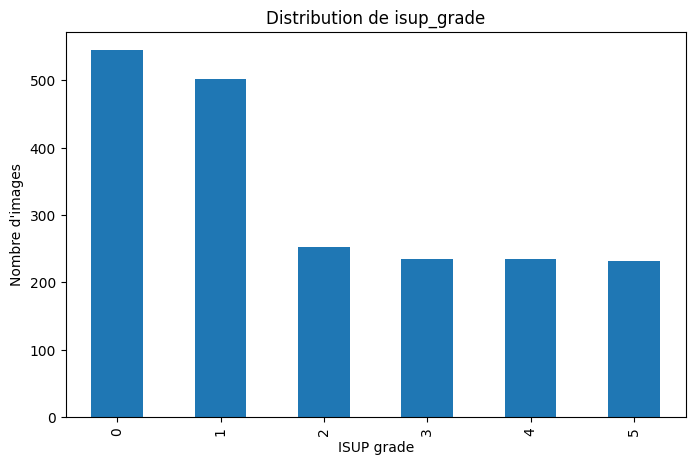

In [ ]:
plt.figure(figsize=(8, 5))
train_df["isup_grade"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribution de isup_grade")
plt.xlabel("ISUP grade")
plt.ylabel("Nombre d'images")
plt.show()

### 2.b Gleason score

Le `gleason_score` donne aussi une information importante.

Ce n'est pas exactement la même chose que `isup_grade`, mais les deux sont liés.

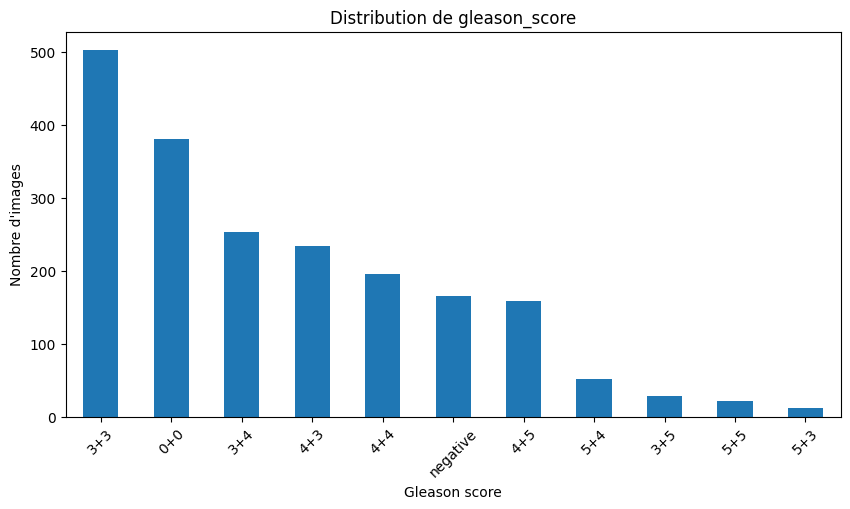

In [ ]:
plt.figure(figsize=(10, 5))
train_df["gleason_score"].value_counts().plot(kind="bar")
plt.title("Distribution de gleason_score")
plt.xlabel("Gleason score")
plt.ylabel("Nombre d'images")
plt.xticks(rotation=45)
plt.show()

### 2.c Data provider

Dans PANDA, il y a plusieurs centres / fournisseurs de données.

C'est important parce que les images peuvent avoir des styles différents.

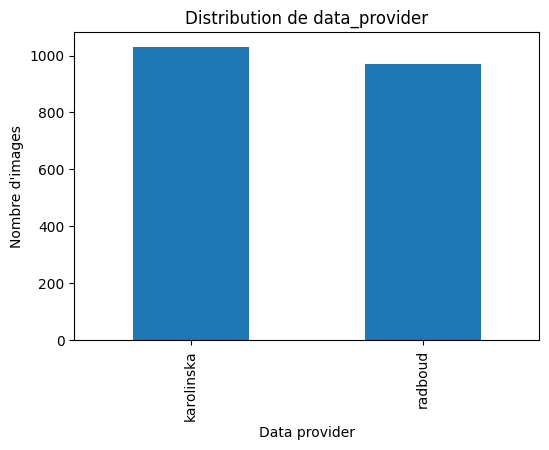

In [ ]:
plt.figure(figsize=(6, 4))
train_df["data_provider"].value_counts().plot(kind="bar")
plt.title("Distribution de data_provider")
plt.xlabel("Data provider")
plt.ylabel("Nombre d'images")
plt.show()

## 3. Analyse Exploratoire des Images (Lames) 


### 3.a Première exploration visuelle

Maintenant on va regarder directement les lames.

Le but ici est simple :
- voir à quoi ressemble une image
- comprendre qu'il y a plusieurs niveaux de résolution
- voir quelques exemples de différentes classes

In [ ]:
# Implémentations de fonctions utilitaires pour les images et les masks (qu'on verra plus tard dans le notebook)

def read_tiff_level(path, level=1):
    with tifffile.TiffFile(path) as tif:
        series = tif.series[0]
        if hasattr(series, "levels") and len(series.levels) > 1:
            level = min(level, len(series.levels) - 1)
            img = series.levels[level].asarray()
        else:
            img = series.asarray()
    return img


def read_slide(image_id, level=1):
    path = TRAIN_IMAGES_DIR / f"{image_id}.tiff"
    return read_tiff_level(path, level=level)


def read_mask(image_id, level=1):
    path = MASKS_DIR / f"{image_id}_mask.tiff"
    if not path.exists():
        return None
    return read_tiff_level(path, level=level)


def show_image(img, title="", figsize=(7, 7), cmap=None):
    plt.figure(figsize=figsize)
    plt.imshow(img, cmap=cmap)
    plt.title(title)
    plt.axis("off")
    plt.show()

def show_side_by_side(img1, img2, title1="", title2="", figsize=(14, 6), cmap2=None):
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    axes[0].imshow(img1)
    axes[0].set_title(title1)
    axes[0].axis("off")

    axes[1].imshow(img2, cmap=cmap2)
    axes[1].set_title(title2)
    axes[1].axis("off")
    plt.show()

def overlay_mask_on_image(image, mask, alpha=0.35):
    """
    Overlay simple :
    - image RGB
    - mask en niveaux entiers
    """
    if mask is None:
        return image

    if len(mask.shape) == 3:
        mask_2d = mask[..., 0]
    else:
        mask_2d = mask

    # petites couleurs simples
    color_map = {
        0: np.array([0, 0, 0]),         # fond
        1: np.array([255, 0, 0]),       # rouge
        2: np.array([0, 255, 0]),       # vert
        3: np.array([0, 0, 255]),       # bleu
        4: np.array([255, 255, 0]),     # jaune
        5: np.array([255, 0, 255]),     # magenta
    }

    overlay = image.copy().astype(np.float32)

    unique_values = np.unique(mask_2d)
    for v in unique_values:
        if v in color_map:
            overlay[mask_2d == v] = (
                (1 - alpha) * overlay[mask_2d == v] + alpha * color_map[v]
            )

    return overlay.astype(np.uint8)

In [ ]:
sample_row = train_df.iloc[0]
sample_id = sample_row["image_id"]

sample_img = read_slide(sample_id, level=IMAGE_LEVEL)

print("Image ID :", sample_id)
print("Shape :", sample_img.shape)
show_image(sample_img, title=f"Slide : {sample_id}")

ValueError: <COMPRESSION.JPEG: 7> requires the 'imagecodecs' package

### 3.b Quelques exemples de lames

In [ ]:
sample_ids = train_df["image_id"].sample(4, random_state=SEED).tolist()

fig, axes = plt.subplots(2, 2, figsize=(12, 12))
axes = axes.flatten()

for ax, image_id in zip(axes, sample_ids):
    img = read_slide(image_id, level=IMAGE_LEVEL)
    ax.imshow(img)
    ax.set_title(image_id)
    ax.axis("off")

plt.tight_layout()
plt.show()

### 3.c Quelques exemples par grade

Ici, on veut voir si visuellement les images changent selon `isup_grade`.

Ce n'est pas toujours évident à l'oeil nu, mais c'est intéressant à regarder.

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for grade in sorted(train_df["isup_grade"].unique()):
    row = train_df[train_df["isup_grade"] == grade].sample(1, random_state=SEED).iloc[0]
    img = read_slide(row["image_id"], level=IMAGE_LEVEL)

    axes[grade].imshow(img)
    axes[grade].set_title(f"ISUP {grade}\n{row['image_id']}")
    axes[grade].axis("off")

plt.tight_layout()
plt.show()

# 5. MASKS

Les masks sont très utiles, car ils permettent de voir les zones annotées.
Même si on n'utilise pas directement les masks pour entraîner notre premier modèle, ils nous aident beaucoup à comprendre les données.

Ici on va faire 3 choses :
- vérifier si on a bien des masks
- afficher image et mask côte à côte
- faire un overlay simple

In [ ]:
train_df["mask_exists"] = train_df["image_id"].apply(
    lambda x: (MASKS_DIR / f"{x}_mask.tiff").exists()
)

train_df["mask_exists"].value_counts()

### 5.a Exemples image + mask

In [ ]:
mask_sample_ids = train_df[train_df["mask_exists"]]["image_id"].sample(3, random_state=SEED).tolist()

for image_id in mask_sample_ids:
    img = read_slide(image_id, level=IMAGE_LEVEL)
    mask = read_mask(image_id, level=IMAGE_LEVEL)

    if mask is not None and len(mask.shape) == 3:
        mask_display = mask[..., 0]
    else:
        mask_display = mask

    print("Image ID :", image_id)
    show_side_by_side(img, mask_display, title1="Image", title2="Mask", cmap2="viridis")

### 5.b Overlay image + mask

C'est souvent la visualisation la plus parlante, car on voit directement où se trouvent certaines zones annotées.

In [ ]:
for image_id in mask_sample_ids:
    img = read_slide(image_id, level=IMAGE_LEVEL)
    mask = read_mask(image_id, level=IMAGE_LEVEL)

    if mask is not None and len(mask.shape) == 3:
        mask_2d = mask[..., 0]
    else:
        mask_2d = mask

    overlay = overlay_mask_on_image(img, mask_2d, alpha=0.35)

    print("Image ID :", image_id)
    show_side_by_side(img, overlay, title1="Image originale", title2="Overlay image + mask")

### 4.c Valeurs présentes dans quelques masks

Ici on regarde juste les valeurs qu'on trouve.

Le but n'est pas de faire une analyse experte très poussée du mask, mais surtout de voir qu'il ne s'agit pas d'une simple image noire et blanche.

In [ ]:
for image_id in mask_sample_ids:
    mask = read_mask(image_id, level=IMAGE_LEVEL)
    if mask is not None and len(mask.shape) == 3:
        mask = mask[..., 0]

    print(image_id, "-> valeurs uniques dans le mask :", np.unique(mask))

## 6. Préprocessing

Les images entières sont beaucoup trop grandes.
On ne peut pas envoyer directement une grande lame dans un CNN classique.
    
La solution simple et classique est :
- découper l'image en petits morceaux
- garder les morceaux les plus utiles
- ensuite travailler avec ces morceaux

Ces petits morceaux sont nommés les `tiles`.

In [ ]:
def pad_image(img, tile_size=128, pad_value=255):
    h, w, c = img.shape

    pad_h = (tile_size - h % tile_size) % tile_size
    pad_w = (tile_size - w % tile_size) % tile_size

    if pad_h > 0 or pad_w > 0:
        img = np.pad(
            img,
            ((0, pad_h), (0, pad_w), (0, 0)),
            mode="constant",
            constant_values=pad_value
        )
    return img

def extract_tiles(img, tile_size=128):
    img = pad_image(img, tile_size=tile_size)
    h, w, _ = img.shape

    tiles = []
    coords = []

    for y in range(0, h, tile_size):
        for x in range(0, w, tile_size):
            tile = img[y:y+tile_size, x:x+tile_size]
            tiles.append(tile)
            coords.append((y, x))

    return np.array(tiles), coords

### 6.a Score simple pour repérer les tiles intéressantes

Une grande partie des images est blanche ou peu informative.
On va donc donner un score à chaque tile.

Ici :
- on regarde la part non blanche
- on ajoute un peu de texture

In [ ]:
def compute_tissue_score(tile):
    tile_float = tile.astype(np.float32)

    white_mask = (tile_float.mean(axis=2) > 220)
    non_white_ratio = 1.0 - white_mask.mean()

    std_intensity = tile_float.std() / 255.0

    score = non_white_ratio + 0.5 * std_intensity
    return score

def select_top_tiles(img, tile_size=128, n_tiles=16):
    tiles, coords = extract_tiles(img, tile_size=tile_size)
    scores = np.array([compute_tissue_score(tile) for tile in tiles])

    top_indices = np.argsort(scores)[::-1][:n_tiles]

    selected_tiles = tiles[top_indices]
    selected_coords = [coords[i] for i in top_indices]
    selected_scores = scores[top_indices]

    # on remet dans un ordre spatial propre
    order = np.argsort([y * 100000 + x for (y, x) in selected_coords])
    selected_tiles = selected_tiles[order]
    selected_coords = [selected_coords[i] for i in order]
    selected_scores = selected_scores[order]

    # si jamais on n'a pas assez de tiles
    if len(selected_tiles) < n_tiles:
        blank_tile = np.ones((tile_size, tile_size, 3), dtype=np.uint8) * 255
        pad_count = n_tiles - len(selected_tiles)

        selected_tiles = list(selected_tiles)
        selected_coords = list(selected_coords)
        selected_scores = list(selected_scores)

        for _ in range(pad_count):
            selected_tiles.append(blank_tile)
            selected_coords.append((-1, -1))
            selected_scores.append(0.0)

        selected_tiles = np.array(selected_tiles)
        selected_scores = np.array(selected_scores)

    return selected_tiles, selected_coords, selected_scores

def make_tile_mosaic(tiles, grid_size=4):
    rows = []
    idx = 0
    for _ in range(grid_size):
        row = np.concatenate(tiles[idx:idx+grid_size], axis=1)
        rows.append(row)
        idx += grid_size

    mosaic = np.concatenate(rows, axis=0)
    return mosaic

### 6.b Test sur une image

On prend une image, on extrait les tiles, on garde les meilleures, puis on reconstruit une mosaïque.

In [ ]:
row = train_df.iloc[0]
image_id = row["image_id"]

img = read_slide(image_id, level=IMAGE_LEVEL)
tiles, coords, scores = select_top_tiles(img, tile_size=TILE_SIZE, n_tiles=N_TILES)
mosaic = make_tile_mosaic(tiles, grid_size=GRID_SIZE)

print("Image ID :", image_id)
print("Tiles shape :", tiles.shape)
print("Mosaic shape :", mosaic.shape)

show_image(img, title="Image d'origine")
show_image(mosaic, title="Mosaïque des meilleures tiles")

### 6.c Voir les tiles une par une

In [ ]:
fig, axes = plt.subplots(GRID_SIZE, GRID_SIZE, figsize=(12, 12))
axes = axes.flatten()

for i, ax in enumerate(axes):
    ax.imshow(tiles[i])
    ax.set_title(f"score={scores[i]:.3f}")
    ax.axis("off")

plt.tight_layout()
plt.show()

### 6.d Fonction complète de preprocessing

Cette fonction prend une image, construit sa mosaïque, puis la sauvegarde.
Comme ça, on pourra l'utiliser ensuite pour tout un sous-ensemble du dataset.

In [ ]:
def process_one_slide(image_id,
                      image_dir,
                      output_dir,
                      tile_size=128,
                      n_tiles=16,
                      grid_size=4,
                      level=1,
                      save_format="png"):

    image_path = image_dir / f"{image_id}.tiff"

    try:
        img = read_tiff_level(image_path, level=level)
        tiles, coords, scores = select_top_tiles(img, tile_size=tile_size, n_tiles=n_tiles)
        mosaic = make_tile_mosaic(tiles, grid_size=grid_size)

        output_path = output_dir / f"{image_id}.{save_format}"

        mosaic_bgr = cv2.cvtColor(mosaic, cv2.COLOR_RGB2BGR)
        cv2.imwrite(str(output_path), mosaic_bgr)

        result = {
            "image_id": image_id,
            "status": "ok",
            "saved_path": str(output_path),
            "mean_tile_score": float(np.mean(scores)),
            "max_tile_score": float(np.max(scores)),
            "min_tile_score": float(np.min(scores)),
        }

        del img, tiles, mosaic
        gc.collect()

        return result

    except Exception as e:
        return {
            "image_id": image_id,
            "status": "error",
            "saved_path": None,
            "mean_tile_score": np.nan,
            "max_tile_score": np.nan,
            "min_tile_score": np.nan,
            "error_message": str(e)
        }

all_results = []

for image_id in tqdm(train_df["image_id"].tolist()):
    res = process_one_slide(
        image_id=image_id,
        image_dir=TRAIN_IMAGES_DIR,
        output_dir=PREPROCESS_DIR,
        tile_size=TILE_SIZE,
        n_tiles=N_TILES,
        grid_size=GRID_SIZE,
        level=IMAGE_LEVEL,
        save_format="png"
    )
    all_results.append(res)

prep_df = pd.DataFrame(all_results)

print(prep_df["status"].value_counts())
display(prep_df.head())

In [ ]:
train_preprocessed_df = train_df.merge(prep_df, on="image_id", how="left")
train_preprocessed_df = train_preprocessed_df[train_preprocessed_df["status"] == "ok"].reset_index(drop=True)

print(train_preprocessed_df.shape)
display(train_preprocessed_df.head())

preprocessed_csv_path = WORK_DIR / "train_preprocessed.csv"
train_preprocessed_df.to_csv(preprocessed_csv_path, index=False)
print("Sauvegardé ici :", preprocessed_csv_path)

## 7. Baseline model

Maintenant, construisons un premier modèle simple.

La stratégie est la suivante :
- chaque mosaïque contient 16 tiles
- on redécoupe la mosaïque en 16 tiles
- chaque tile passe dans EfficientNet-B0
- on récupère les logits de chaque tile
- on fait la moyenne des logits
- on obtient une prédiction finale pour la slide

In [ ]:
model_df = train_preprocessed_df.copy()

train_split_df, temp_df = train_test_split(
    model_df,
    test_size=0.30,
    stratify=model_df["isup_grade"],
    random_state=SEED
)

valid_split_df, test_split_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["isup_grade"],
    random_state=SEED
)

train_split_df = train_split_df.reset_index(drop=True)
valid_split_df = valid_split_df.reset_index(drop=True)
test_split_df = test_split_df.reset_index(drop=True)

print("Train :", train_split_df.shape)
print("Valid :", valid_split_df.shape)
print("Test  :", test_split_df.shape)

In [ ]:
def split_mosaic_into_tiles(mosaic, grid_size=4):
    h, w, c = mosaic.shape
    tile_h = h // grid_size
    tile_w = w // grid_size

    tiles = []
    for i in range(grid_size):
        for j in range(grid_size):
            tile = mosaic[
                i * tile_h:(i + 1) * tile_h,
                j * tile_w:(j + 1) * tile_w
            ]
            tiles.append(tile)

    return np.array(tiles)

In [ ]:
train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

valid_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
class PandaTileDataset(Dataset):
    def __init__(self, dataframe, transform=None, grid_size=4):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
        self.grid_size = grid_size

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = row["saved_path"]
        label = int(row["isup_grade"])

        mosaic = cv2.imread(img_path)
        mosaic = cv2.cvtColor(mosaic, cv2.COLOR_BGR2RGB)

        tiles = split_mosaic_into_tiles(mosaic, grid_size=self.grid_size)

        processed_tiles = []
        for tile in tiles:
            if self.transform is not None:
                tile = self.transform(tile)
            processed_tiles.append(tile)

        processed_tiles = torch.stack(processed_tiles, dim=0)
        label = torch.tensor(label, dtype=torch.long)

        return processed_tiles, label

In [ ]:
train_dataset = PandaTileDataset(train_split_df, transform=train_transform, grid_size=GRID_SIZE)
valid_dataset = PandaTileDataset(valid_split_df, transform=valid_transform, grid_size=GRID_SIZE)
test_dataset  = PandaTileDataset(test_split_df,  transform=valid_transform, grid_size=GRID_SIZE)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

batch_tiles, batch_labels = next(iter(train_loader))
print("Batch tiles shape :", batch_tiles.shape)
print("Batch labels shape :", batch_labels.shape)

In [ ]:
class TileAggregationModel(nn.Module):
    def __init__(self, model_name="efficientnet_b0", num_classes=6, pretrained=True):
        super().__init__()
        self.backbone = timm.create_model(
            model_name,
            pretrained=pretrained,
            num_classes=num_classes
        )

    def forward(self, x):
        # x : (B, T, C, H, W)
        B, T, C, H, W = x.shape
        x = x.view(B * T, C, H, W)

        tile_logits = self.backbone(x)      # (B*T, num_classes)
        tile_logits = tile_logits.view(B, T, -1)

        slide_logits = tile_logits.mean(dim=1)
        return slide_logits, tile_logits

In [ ]:
baseline_model = TileAggregationModel(
    model_name="efficientnet_b0",
    num_classes=NUM_CLASSES,
    pretrained=True
).to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(baseline_model.parameters(), lr=LR)

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    all_preds = []
    all_labels = []

    for tiles, labels in tqdm(loader, leave=False):
        tiles = tiles.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        slide_logits, _ = model(tiles)
        loss = criterion(slide_logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * labels.size(0)

        preds = torch.argmax(slide_logits, dim=1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    loss_value = running_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average="macro")

    return loss_value, acc, f1

In [ ]:
def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for tiles, labels in tqdm(loader, leave=False):
            tiles = tiles.to(device)
            labels = labels.to(device)

            slide_logits, _ = model(tiles)
            loss = criterion(slide_logits, labels)

            running_loss += loss.item() * labels.size(0)

            preds = torch.argmax(slide_logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    loss_value = running_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average="macro")

    return loss_value, acc, f1, all_labels, all_preds

In [ ]:
history = {
    "train_loss": [],
    "train_acc": [],
    "train_f1": [],
    "valid_loss": [],
    "valid_acc": [],
    "valid_f1": []
}

best_valid_f1 = -1
best_model_path = WORK_DIR / "best_baseline_model.pth"

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")

    train_loss, train_acc, train_f1 = train_one_epoch(
        baseline_model, train_loader, criterion, optimizer, DEVICE
    )

    valid_loss, valid_acc, valid_f1, _, _ = evaluate(
        baseline_model, valid_loader, criterion, DEVICE
    )

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["train_f1"].append(train_f1)
    history["valid_loss"].append(valid_loss)
    history["valid_acc"].append(valid_acc)
    history["valid_f1"].append(valid_f1)

    print(f"Train loss : {train_loss:.4f} | Train acc : {train_acc:.4f} | Train F1 : {train_f1:.4f}")
    print(f"Valid loss : {valid_loss:.4f} | Valid acc : {valid_acc:.4f} | Valid F1 : {valid_f1:.4f}")

    if valid_f1 > best_valid_f1:
        best_valid_f1 = valid_f1
        torch.save(baseline_model.state_dict(), best_model_path)
        print("Meilleur modèle sauvegardé")

In [ ]:
epochs = range(1, NUM_EPOCHS + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, history["train_loss"], label="Train")
plt.plot(epochs, history["valid_loss"], label="Valid")
plt.title("Loss")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs, history["train_acc"], label="Train")
plt.plot(epochs, history["valid_acc"], label="Valid")
plt.title("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs, history["train_f1"], label="Train")
plt.plot(epochs, history["valid_f1"], label="Valid")
plt.title("Macro F1")
plt.legend()
plt.show()

In [ ]:
baseline_model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))

test_loss, test_acc, test_f1, y_true, y_pred = evaluate(
    baseline_model, test_loader, criterion, DEVICE
)

print("Résultats sur le test set")
print("Test loss    :", round(test_loss, 4))
print("Test accuracy:", round(test_acc, 4))
print("Test macro F1:", round(test_f1, 4))

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 6))
plt.imshow(cm)
plt.title("Matrice de confusion - Baseline")
plt.colorbar()
plt.xlabel("Classe prédite")
plt.ylabel("Classe vraie")
plt.xticks(range(NUM_CLASSES))
plt.yticks(range(NUM_CLASSES))
plt.show()

print(cm)

In [ ]:
print(classification_report(y_true, y_pred, digits=4))

### 8. MIL simple


Au lieu de faire la moyenne des logits finaux, on va :
- extraire des features pour chaque tile
- faire la moyenne des features
- passer le résultat dans une petite tête de classification

C'est plus proche de l'idée du MIL.

In [ ]:
class SimpleMILModel(nn.Module):
    def __init__(self, model_name="efficientnet_b0", num_classes=6, pretrained=True):
        super().__init__()

        self.encoder = timm.create_model(
            model_name,
            pretrained=pretrained,
            num_classes=0,
            global_pool="avg"
        )

        feature_dim = self.encoder.num_features
        self.classifier = nn.Linear(feature_dim, num_classes)

    def forward(self, x):
        # x : (B, T, C, H, W)
        B, T, C, H, W = x.shape
        x = x.view(B * T, C, H, W)

        tile_features = self.encoder(x)            # (B*T, F)
        tile_features = tile_features.view(B, T, -1)

        slide_features = tile_features.mean(dim=1) # (B, F)
        slide_logits = self.classifier(slide_features)

        return slide_logits, tile_features

In [ ]:
mil_model = SimpleMILModel(
    model_name="efficientnet_b0",
    num_classes=NUM_CLASSES,
    pretrained=True
).to(DEVICE)

criterion_mil = nn.CrossEntropyLoss()
optimizer_mil = optim.Adam(mil_model.parameters(), lr=LR)

In [ ]:
history_mil = {
    "train_loss": [],
    "train_acc": [],
    "train_f1": [],
    "valid_loss": [],
    "valid_acc": [],
    "valid_f1": []
}

best_valid_f1_mil = -1
best_mil_path = WORK_DIR / "best_mil_model.pth"

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")

    train_loss, train_acc, train_f1 = train_one_epoch(
        mil_model, train_loader, criterion_mil, optimizer_mil, DEVICE
    )

    valid_loss, valid_acc, valid_f1, _, _ = evaluate(
        mil_model, valid_loader, criterion_mil, DEVICE
    )

    history_mil["train_loss"].append(train_loss)
    history_mil["train_acc"].append(train_acc)
    history_mil["train_f1"].append(train_f1)
    history_mil["valid_loss"].append(valid_loss)
    history_mil["valid_acc"].append(valid_acc)
    history_mil["valid_f1"].append(valid_f1)

    print(f"Train loss : {train_loss:.4f} | Train acc : {train_acc:.4f} | Train F1 : {train_f1:.4f}")
    print(f"Valid loss : {valid_loss:.4f} | Valid acc : {valid_acc:.4f} | Valid F1 : {valid_f1:.4f}")

    if valid_f1 > best_valid_f1_mil:
        best_valid_f1_mil = valid_f1
        torch.save(mil_model.state_dict(), best_mil_path)
        print("Meilleur modèle MIL sauvegardé")

In [ ]:
mil_model.load_state_dict(torch.load(best_mil_path, map_location=DEVICE))

test_loss_mil, test_acc_mil, test_f1_mil, y_true_mil, y_pred_mil = evaluate(
    mil_model, test_loader, criterion_mil, DEVICE
)

print("Résultats MIL simple")
print("Test loss    :", round(test_loss_mil, 4))
print("Test accuracy:", round(test_acc_mil, 4))
print("Test macro F1:", round(test_f1_mil, 4))

In [ ]:
cm_mil = confusion_matrix(y_true_mil, y_pred_mil)

plt.figure(figsize=(7, 6))
plt.imshow(cm_mil)
plt.title("Matrice de confusion - MIL simple")
plt.colorbar()
plt.xlabel("Classe prédite")
plt.ylabel("Classe vraie")
plt.xticks(range(NUM_CLASSES))
plt.yticks(range(NUM_CLASSES))
plt.show()

print(cm_mil)

## 9. Interprétabilité simple

On va regarder :
- quelques prédictions justes
- quelques prédictions fausses
- les tiles d'une mosaïque

Le but est de commencer à réfléchir aux erreurs du modèle.

In [ ]:
test_results_df = test_split_df.copy().reset_index(drop=True)
test_results_df["y_true"] = y_true
test_results_df["y_pred"] = y_pred
test_results_df["correct"] = (test_results_df["y_true"] == test_results_df["y_pred"]).astype(int)

display(test_results_df.head())

In [ ]:
correct_examples = test_results_df[test_results_df["correct"] == 1].head(3)
wrong_examples = test_results_df[test_results_df["correct"] == 0].head(3)

print("Exemples corrects :", len(correct_examples))
print("Exemples faux :", len(wrong_examples))

In [ ]:
def show_prediction_examples(df_examples, title):
    print("\n" + title)

    for _, row in df_examples.iterrows():
        mosaic = cv2.imread(row["saved_path"])
        mosaic = cv2.cvtColor(mosaic, cv2.COLOR_BGR2RGB)

        plt.figure(figsize=(6, 6))
        plt.imshow(mosaic)
        plt.title(
            f"image_id={row['image_id']}\ntrue={row['y_true']} | pred={row['y_pred']}"
        )
        plt.axis("off")
        plt.show()

In [ ]:
show_prediction_examples(correct_examples, "Exemples bien classés")
show_prediction_examples(wrong_examples, "Exemples mal classés")

### 9.a Voir les tiles d'une prédiction fausse

Parfois la mosaïque semble simple, mais certaines tiles sont difficiles.

C'est pour ça qu'il est utile de regarder les morceaux séparément.

In [ ]:
if len(wrong_examples) > 0:
    row = wrong_examples.iloc[0]
    mosaic = cv2.imread(row["saved_path"])
    mosaic = cv2.cvtColor(mosaic, cv2.COLOR_BGR2RGB)
    tiles = split_mosaic_into_tiles(mosaic, grid_size=GRID_SIZE)

    fig, axes = plt.subplots(GRID_SIZE, GRID_SIZE, figsize=(12, 12))
    axes = axes.flatten()

    for i, ax in enumerate(axes):
        ax.imshow(tiles[i])
        ax.axis("off")
        ax.set_title(f"Tile {i+1}")

    plt.suptitle(
        f"Tiles d'une image mal classée\ntrue={row['y_true']} | pred={row['y_pred']}",
        fontsize=14
    )
    plt.tight_layout()
    plt.show()

## 10. Comparaison simple entre les deux modèles

Comparons la baseline et la version MIL simple.
Le but n'est pas de dire qu'on a déjà un modèle parfait mais simplement de voir si l'idée d'agréger les features aide un peu.

In [ ]:
comparison_df = pd.DataFrame({
    "model": ["Baseline logits mean", "Simple MIL"],
    "test_accuracy": [test_acc, test_acc_mil],
    "test_macro_f1": [test_f1, test_f1_mil]
})

comparison_df

In [ ]:
comparison_df.set_index("model")[["test_accuracy", "test_macro_f1"]].plot(
    kind="bar",
    figsize=(8, 5)
)
plt.title("Comparaison des modèles")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

## 11. Conclusion

Dans ce notebook, on a fait tout le chemin pas à pas.

On a commencé par comprendre les données.
Ensuite on a regardé les lames et les masks.

Puis on a construit un préprocessing simple avec des tiles.

Après ça, on a entraîné :
- une baseline simple avec EfficientNet-B0
- une version un peu plus proche du MIL

Enfin, on a regardé quelques prédictions et quelques erreurs.

Ce notebook permet de comprendre le problème, de construire un pipeline propre, et de préparer une suite plus ambitieuse.

### Idées pour aller plus loin

Plus tard, on pourra améliorer :
- la sélection des tiles
- la taille des images
- une meilleure interprétabilité